# Function 4

<b> Description of the Sample Application:</b> Address the challenge of optimally placing products across warehouses for a business with high online sales, where accurate calculations are costly and only feasible biweekly. To speed up decision-making, an ML model approximates these results within hours. The model has four hyperparameters to tune, and its output reflects the difference from the expensive baseline. Because the system is dynamic and full of local optima, it requires careful tuning and robust validation to find reliable, near-optimal solutions. 



## Change Log

| Date | Week | Changes Made |
|---|---|---|
| 22/07/2026 | Week 1 | 1. Initial Version with 10 Data Point |
| 22/07/2026 | Week 2 | 1. Added Change Log and Progress Log.<br>2. Added new data point. |


## Progress Log

| Week | Query Submitted | Output Received | Best So Far (y) | Acquisition | κ (kappa) | Kernel | Strategy Notes |
|---|---|---|---|---|---|---|---|
|  |  |  |  |  |  |  |  |
| Week 1 | 0.383979-0.383515-0.340147-0.445246 | -0.06634074624810848 | -0.066341 | UCB | 2.5 | RBF | Exploration-heavy baseline; big jump over initial best |
| Week 2 | *(computed below)* | *(pending)* | *(pending)* | UCB | 2.0 | RBF vs Matern (best by LML) | Slightly reduced exploration per 8-week plan; kernel comparison added |


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel, Matern
from scipy.optimize import minimize
from scipy.stats import norm

from plotting_utils import (plot_convergence, plot_parallel_coordinates)

# Load and Analyse the Data

In [13]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X0      = np.load(input_file)
Y0      = np.load(output_file)


# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.383979, 0.383515, 0.340147, 0.445246]   , dtype=np.float64)    # from input.txt
Y_w1_new_point = np.array([-0.06634074624810848]                     , dtype=np.float64)    # from output.txt

# Append the new data points
X_updated      = np.vstack((X0, X_w1_new_point))
Y_updated      = np.append(Y0, Y_w1_new_point)

#print(X_updated)
#print(Y_updated)

# Save the updated arrays
#np.save(r"initial_inputs.npy", X_updated)
#np.save(r"initial_outputs.npy", Y_updated)

In [19]:
# Assign X = X_updated and Y = Y_updated
X          = X_updated
Y          = Y_updated

# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", Y.shape)
print("Outputs:\n", Y)
print()

print(f"y Range: [: {Y.min()}, {Y.max()}]")
best_idx   = np.argmax(Y)
print(f"Best point: x = {X[best_idx]}, y = {Y[best_idx]}")
print()

# Converting the Input and Output into a DataFram
df         = pd.DataFrame(X, columns = [f'X_{i+1}' for i in range(X.shape[1])])
df['Y'] = Y
print("Data Frame:\n", df)


Input  Shape: (31, 4)
Inputs:
 [[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.335

# Data Exploration

In [22]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
              X_1        X_2        X_3        X_4          Y
count  31.000000  31.000000  31.000000  31.000000  31.000000
mean    0.537747   0.474109   0.461643   0.473166 -16.684644
std     0.290471   0.304183   0.258207   0.287544   7.665805
min     0.037825   0.006250   0.042186   0.081517 -32.625660
25%     0.266542   0.155668   0.229306   0.225204 -21.048893
50%     0.577766   0.499588   0.438806   0.494932 -16.026400
75%     0.774002   0.741294   0.708006   0.746945 -12.711725
max     0.985622   0.919592   0.939178   0.999483  -0.066341


In [24]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())

Missing Values in the Dataset
 X_1    0
X_2    0
X_3    0
X_4    0
Y      0
dtype: int64


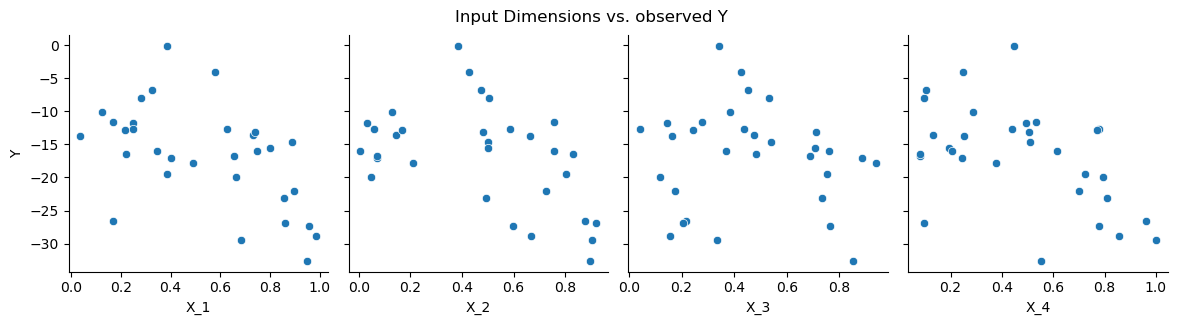

In [30]:
# Pairwise Scatter Plot, showing relationship of y for each input
sns.pairplot(df, y_vars = ['Y'], x_vars = ['X_1', 'X_2', 'X_3', 'X_4'], height = 3)
plt.suptitle("Input Dimensions vs. observed Y", y = 1.05)
plt.show()

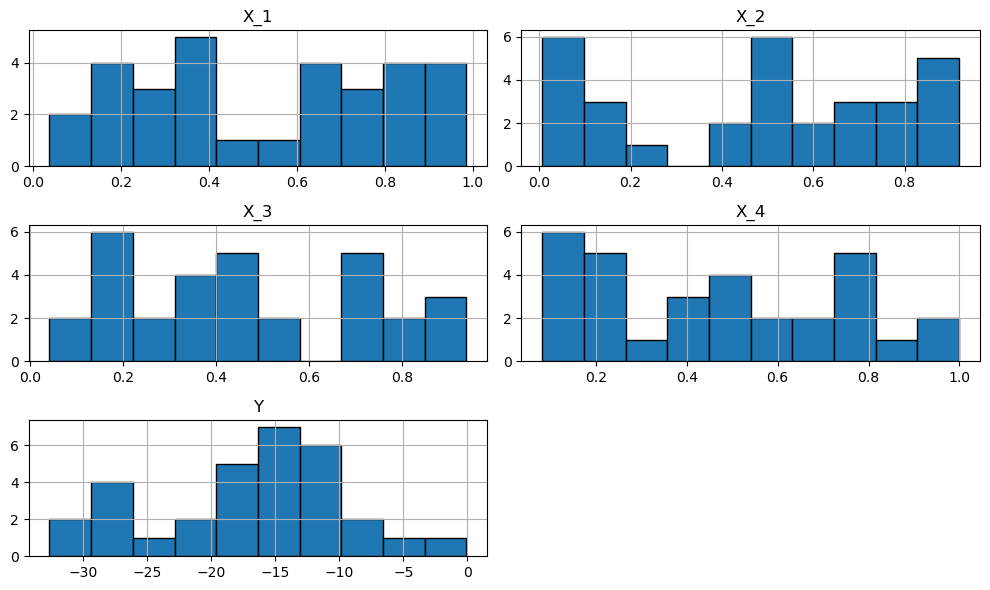

In [32]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'k' )
plt.tight_layout()
plt.show()

In [34]:
# Understanding Correlation between each input with y
labels      = ["X_1", "X_2", "X_3", "X_4"]
print("Correlation of each input with y:\n")

for i, lab in enumerate(labels):
    corr = np.corrcoef(X[:, i], Y)[0, 1]
    print(f" corr({lab}, Y) = {corr}")

Correlation of each input with y:

 corr(X_1, Y) = -0.5314007063325927
 corr(X_2, Y) = -0.46539889815740404
 corr(X_3, Y) = -0.11246664165179814
 corr(X_4, Y) = -0.49431869348001634


<Axes: >

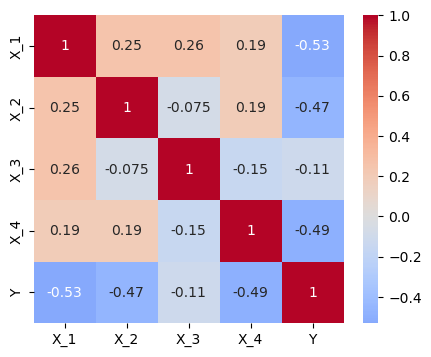

In [36]:
# Plotting the Correlation heatmap
plt.figure(figsize = (5, 4))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm", center = 0)

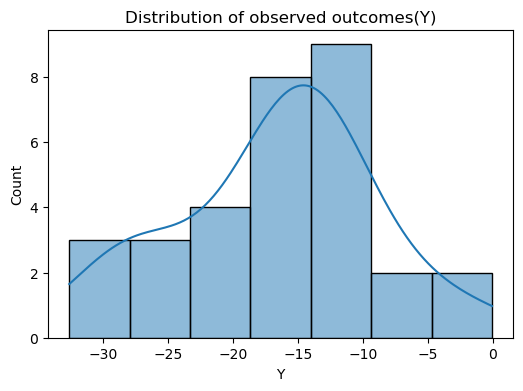

In [38]:
# Plot the Histogram for y to check for Outliers
plt.figure(figsize = (6,4))
sns.histplot(df['Y'], kde = True)
plt.title("Distribution of observed outcomes(Y)")
plt.show()

# Initialize Gaussian Process

In [27]:
#Define the kernel and initialise the GP model

kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [0.3, 0.3, 0.3, 0.3], length_scale_bounds = (1e-2, 2.0)) \
                + WhiteKernel(noise_level = 1e-3, noise_level_bounds = (1e-6, 1e-1))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = True, n_restarts_optimizer = 10, random_state = 0 )

# Fit the Gaussian Processes to existing data

In [30]:
# Train the model

gpr.fit(X, y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  2.01**2 * RBF(length_scale=[0.75, 0.666, 0.756, 0.721]) + WhiteKernel(noise_level=1e-06)


C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [34]:
n_candidates = 50000
candidates   = np.random.uniform(0, 1, size = (n_candidates, 4))

mu, std      = gpr.predict(candidates, return_std = True)

# Setting a higher beta(= 2.5) for Week -1
beta         = 2.5
ucb          = mu + beta * std

best_ucb_idx   = np.argmax(ucb)
next_point     = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"Predicted Mean(μ): {mu[best_ucb_idx]:.6e}")
print(f"Predicted Std (σ): {std[best_ucb_idx]:.6e}")
print(f"UCB Score: {ucb[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.3839786  0.38351485 0.34014711 0.4452459 ]
Predicted Mean(μ): -1.442484e+00
Predicted Std (σ): 6.674486e-01
UCB Score: 2.261375e-01


# Week 2: Evaluating Kernel - RBF vs. Matern

In [41]:
Y_mean, Y_std  = Y.mean(), Y.std()
Y_norm         = (Y - Y_mean) / Y_std

kernel_rbf     = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [0.3, 0.3, 0.3, 0.3], length_scale_bounds = (1e-2, 2.0)) \
                    + WhiteKernel(noise_level = 1e-3, noise_level_bounds = (1e-6, 1e-1))

kernel_matern  = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(length_scale = [0.3, 0.3, 0.3, 0.3], length_scale_bounds = (1e-2, 2.0), nu = 2.5) \
                    + WhiteKernel(noise_level = 1e-3, noise_level_bounds = (1e-6, 1e-1))

gpr_rbf        = GaussianProcessRegressor(kernel = kernel_rbf, n_restarts_optimizer = 10, random_state = 0)
gpr_rbf.fit(X, Y_norm)

gpr_matern     = GaussianProcessRegressor(kernel = kernel_matern, n_restarts_optimizer = 10, random_state = 0)
gpr_matern.fit(X, Y_norm)

print("Learned kernel ( RBF)  :", gpr_rbf.kernel_)
print("Log-marginal-likelihood:", gpr_rbf.log_marginal_likelihood_value_)
print()
print("Learned kernel (Matern):", gpr_matern.kernel_)
print("Log-marginal-likelihood:", gpr_matern.log_marginal_likelihood_value_)

if gpr_rbf.log_marginal_likelihood_value_ >= gpr_matern.log_marginal_likelihood_value_:
    chosen_kernel, chosen_name = kernel_rbf, "RBF"
else:
    chosen_kernel, chosen_name = kernel_matern, "Matern (nu = 2.5)"

print()
print(f"Chosen kernel for Week 2: {chosen_name}")


C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Learned kernel ( RBF)  : 1.89**2 * RBF(length_scale=[0.737, 0.686, 0.758, 0.657]) + WhiteKernel(noise_level=1e-06)
Log-marginal-likelihood: -17.772687771945478

Learned kernel (Matern): 3.51**2 * Matern(length_scale=[1.69, 1.54, 1.7, 1.54], nu=2.5) + WhiteKernel(noise_level=1e-06)
Log-marginal-likelihood: -17.74144798104138

Chosen kernel for Week 2: Matern (nu = 2.5)


C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


# Week 2: Bayesian Optimisation Function

In [51]:
def upper_confidence_bound(mu, sigma, beta = 2.0):
    """UCB(x) = mean + beta * std. Higher beta favours exploration."""
    return mu + beta * sigma


def expected_improvement(mu, sigma, Y_best, xi = 0.01):
    """EI(x) = E[max(f(x) - f(x_best), 0)]. More conservative than UCB."""
    with np.errstate(divide = 'warn'):
        improvement = mu - Y_best - xi
        Z    = improvement / sigma
        ei   = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei


def suggest_next_point(X, Y, kernel, beta = 2.0, acquisition = 'ucb',
                        n_restarts_optimizer = 10, n_multistart = 50, seed = 42):
    
    Y_mean, Y_std = Y.mean(), Y.std()
    Y_norm        = (Y - Y_mean) / Y_std

    gp            = GaussianProcessRegressor(kernel = kernel, n_restarts_optimizer = n_restarts_optimizer, random_state = seed)
    gp.fit(X, Y_norm)

    n_dims        = X.shape[1]

    def neg_acq(x):
        x = np.atleast_2d(x)
        mu, sigma = gp.predict(x, return_std = True)
        mu        = mu * Y_std + Y_mean
        sigma     = sigma * Y_std
        if acquisition == 'ei':
            val   = expected_improvement(mu, sigma, Y.max())
        else:
            val   = upper_confidence_bound(mu, sigma, beta = beta)
        return -val[0]

    rng              = np.random.default_rng(seed)
    
    best_x, best_val = None, np.inf
    
    for _ in range(n_multistart):
        x0 = rng.uniform(0, 1, size=n_dims)
        res = minimize(neg_acq, x0, bounds = [(0, 1)] * n_dims, method = 'L-BFGS-B')
        if res.fun < best_val:
            best_val, best_x = res.fun, res.x

    mu_next, sigma_next = gp.predict(best_x.reshape(1, -1), return_std = True)
    mu_next = mu_next * Y_std + Y_mean
    sigma_next = sigma_next * Y_std

    return {
        'gp': gp,
        'next_x': best_x,
        'acq_value': -best_val,
        'mu': mu_next[0],
        'sigma': sigma_next[0],
    }


# Week 2: Query Selection

In [54]:
result = suggest_next_point(X, Y, chosen_kernel, beta = 2.0, acquisition = 'ucb')

next_x = result['next_x']

print(f"Kernel used            : {chosen_name}")
print(f"Suggested next point   : {next_x}")
print(f"Predicted mean (mu)    : {result['mu']:.6f}")
print(f"Predicted std (sigma)  : {result['sigma']:.6f}")
print(f"UCB score              : {result['acq_value']:.6f}")


C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Kernel used            : Matern (nu = 2.5)
Suggested next point   : [0.44122505 0.43003425 0.27490419 0.43141494]
Predicted mean (mu)    : -0.383547
Predicted std (sigma)  : 0.460734
UCB score              : 0.537922


# Week 2: Portal Submission 

In [56]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
submission_str = f"{next_x[0]:.6f}-{next_x[1]:.6f}-{next_x[2]:.6f}-{next_x[3]:.6f}"
print("Points to be submitted(Week 1):", submission_str)
print()

Points to be submitted(Week 1): 0.441225-0.430034-0.274904-0.431415



# Week 2: Visualise the Acquisition Function and Next Query Point

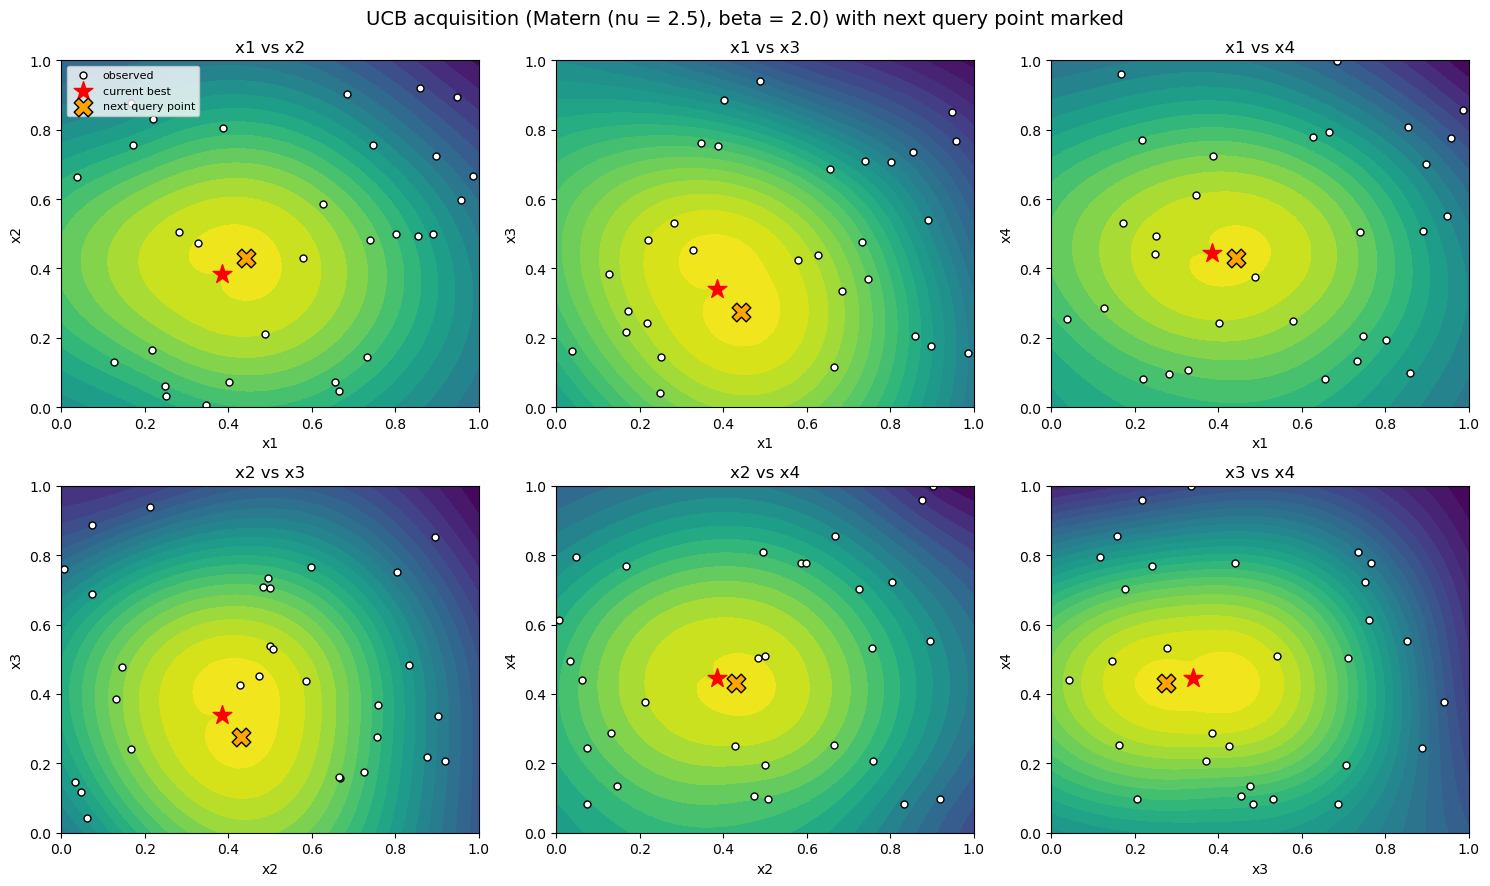

In [60]:
gp         = result['gp']
best_x_obs = X[np.argmax(Y)]

def ucb_full(x, beta = 2.0):
    x = np.atleast_2d(x)
    mu, sigma = gp.predict(x, return_std=True)
    return (mu * Y_std + Y_mean) + beta * (sigma * Y_std)

dim_pairs  = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
grid_n     = 60
grid       = np.linspace(0, 1, grid_n)

fig, axes  = plt.subplots(2, 3, figsize = (15, 9))
for ax, (i, j) in zip(axes.flat, dim_pairs):
    A, B   = np.meshgrid(grid, grid)
    pts    = np.tile(best_x_obs, (grid_n * grid_n, 1))
    pts[:, i] = A.ravel()
    pts[:, j] = B.ravel()
    Z = ucb_full(pts).reshape(grid_n, grid_n)
    ax.contourf(A, B, Z, levels = 25, cmap = 'viridis')
    ax.scatter(X[:, i], X[:, j], c = 'white', edgecolor = 'black', s = 25, label = 'observed')
    ax.scatter(best_x_obs[i], best_x_obs[j], c = 'red', marker = '*', s = 200, label = 'current best')
    ax.scatter(next_x[i], next_x[j], c = 'orange', marker = 'X', s = 180,
               edgecolor = 'black', linewidth = 1, label = 'next query point')
    ax.set_xlabel(f'x{i+1}')
    ax.set_ylabel(f'x{j+1}')
    ax.set_title(f'x{i+1} vs x{j+1}')
axes.flat[0].legend(fontsize = 8, loc = 'upper left')
fig.suptitle(f'UCB acquisition ({chosen_name}, beta = 2.0) with next query point marked', fontsize = 14)
plt.tight_layout()
plt.show()


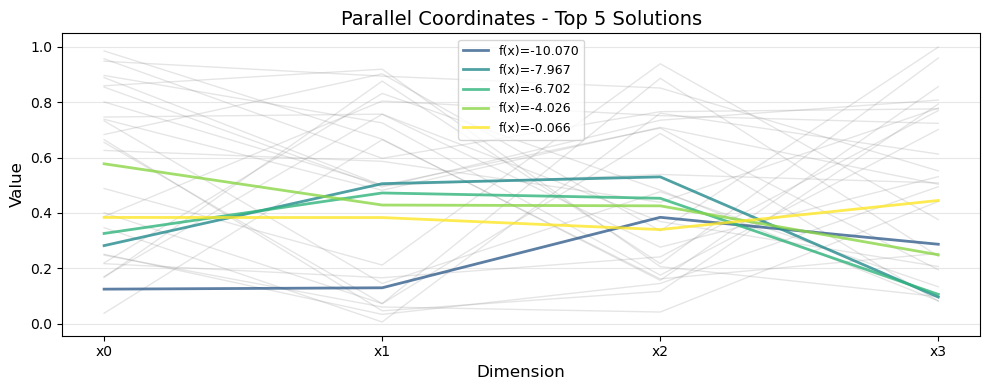

In [62]:
# Parallel coordinates: how does the new best point compare to other top solutions?
plot_parallel_coordinates(X, Y, n_best = 5)
plt.show()


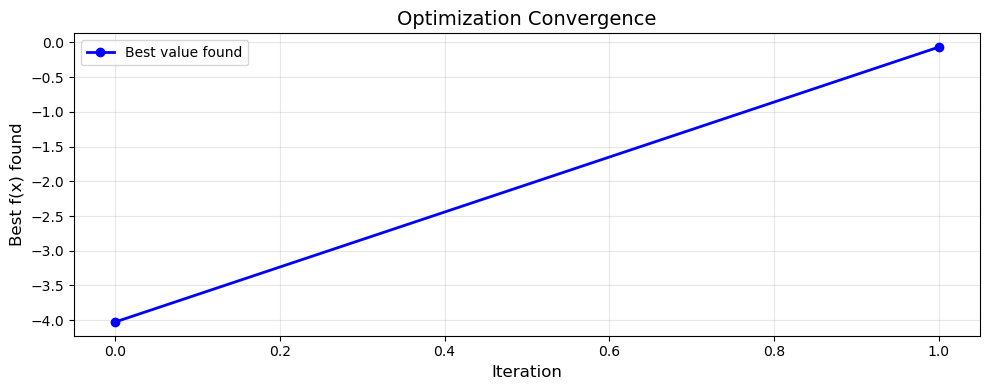

Convergence trace (best value found at each stage): [-4.025542281908162, -0.06634074624810848]


In [64]:
# Convergence so far (initial best -> Week 1 result)
best_values = [-4.025542281908162, Y.max()]
plot_convergence(range(len(best_values)), best_values)
plt.show()

print("Convergence trace (best value found at each stage):", best_values)